## Your API key (30 seconds)

The course model runs on OpenRouter. Give this notebook your issued key in one of two ways:

- **Recommended:** click the key icon in Colab's left sidebar, add a secret named
  `OPENROUTER_API_KEY`, and switch on *Notebook access*. Every course notebook then finds it automatically.
- **Or:** run the cell below and paste the key when asked (it is kept only in this session).

No key? Just press Enter when asked. The notebook switches to the mock model and everything still runs.
Never paste a key into a code cell: notebooks get shared.

In [ ]:
# === Setup: run this cell first ===============================================
# It reads your API key, creates the client, and defines chat(): the ONE function
# every section of this notebook uses to talk to the model.
import json, os, re
from getpass import getpass

MODEL = "openai/gpt-oss-120b"          # the course model on OpenRouter

def load_api_key():
    """Look for the key in Colab Secrets, then the environment, then ask once."""
    try:
        from google.colab import userdata           # only exists on Colab
        key = userdata.get("OPENROUTER_API_KEY")
        if key:
            return key, "Colab secret"
    except Exception:
        pass                                        # not on Colab, or no secret yet
    if os.getenv("OPENROUTER_API_KEY"):
        return os.environ["OPENROUTER_API_KEY"], "environment variable"
    try:
        key = getpass("OpenRouter API key (press Enter to use the mock model): ").strip()
    except Exception:                               # no keyboard available (automated run)
        key = ""
    return (key, "typed in") if key else ("", "none")

API_KEY, KEY_SOURCE = load_api_key()
LIVE = bool(API_KEY)                                # True = real model, False = mock model
client = None
if LIVE:
    from openai import OpenAI                       # the OpenAI SDK speaks OpenRouter's API too
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=API_KEY)

def chat(messages, tools=None, response_format=None, temperature=0.0, max_tokens=600):
    """Send ONE request to the model and return a plain dict:
         {"content": str, "tool_calls": [{"id", "name", "arguments"}], "usage": {...}}
    Everything else in this notebook is built on top of this function."""
    if not LIVE:
        return mock_model(messages, tools, response_format)
    request = dict(model=MODEL, messages=messages, temperature=temperature, max_tokens=max_tokens,
                   extra_body={"reasoning": {"effort": "low"}})   # keep hidden reasoning short and cheap
    if tools:
        request["tools"] = tools
    if response_format:
        request["response_format"] = response_format
    response = client.chat.completions.create(**request)
    message = response.choices[0].message
    calls = [{"id": call.id, "name": call.function.name,
              "arguments": json.loads(call.function.arguments or "{}")}
             for call in (message.tool_calls or [])]
    usage = response.usage
    return {"content": message.content or "", "tool_calls": calls,
            "usage": {"prompt_tokens": usage.prompt_tokens, "completion_tokens": usage.completion_tokens,
                      "total_tokens": usage.total_tokens}}

print("Model  :", MODEL)
print("Key    :", KEY_SOURCE)
print("Mode   :", "LIVE - real model replies" if LIVE else "MOCK - canned replies, real shapes, zero cost")

### The mock model (read later, or never)

When there is no key, `chat()` hands the request to the function below. It answers the
handful of questions used in this notebook with fixed rules. You do not need to understand
it now; it exists so that every mechanism you build today can run and be tested without spending credit.

In [ ]:
def _mock_reply(content="", calls=None):
    return {"content": content, "tool_calls": calls or [],
            "usage": {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}}

def mock_model(messages, tools=None, response_format=None):
    """A stand-in model: fixed rules, real reply shapes. Understands only this notebook's questions."""
    user_text = next((m["content"] for m in reversed(messages) if m["role"] == "user"), "")
    lower = user_text.lower()
    system_text = " ".join(m["content"] for m in messages if m["role"] == "system").lower()
    tool_names = [t["function"]["name"] for t in (tools or [])]
    tools_already_used = {call["function"]["name"] for m in messages if m["role"] == "assistant"
                          for call in m.get("tool_calls", [])}
    tool_results = [m["content"] for m in messages if m["role"] == "tool"]

    # 1) Decide whether a tool is needed: notes first, then the calculator.
    if "search_local_notes" in tool_names and "search_local_notes" not in tools_already_used:
        topic = re.search(r"what is an? ([a-z ]+?)(?:[,?.]|$)", lower)
        if topic:
            return _mock_reply(calls=[{"id": "call_notes_1", "name": "search_local_notes",
                                       "arguments": {"query": topic.group(1).strip()}}])
    arithmetic = re.search(r"(\d[\d\s.]*[*+\-/x×][\d\s.*+\-/x×()]*\d)", lower)
    if "calculator" in tool_names and "calculator" not in tools_already_used and arithmetic:
        expression = arithmetic.group(1).replace("×", "*").replace("x", "*").replace(" ", "")
        return _mock_reply(calls=[{"id": "call_calc_1", "name": "calculator",
                                   "arguments": {"expression": expression}}])

    # 2) A JSON schema was requested: answer in that shape.
    if response_format:
        summary = " ".join(tool_results) if tool_results else f"A short mock answer about: {user_text}"
        answer = {"topic": user_text[:60], "summary": summary[:300], "key_points": [summary[:120]],
                  "tools_used": sorted(tools_already_used), "confidence": 0.8}
        return _mock_reply(json.dumps(answer))

    # 3) Plain-text answers for the questions in sections 1 and 2.
    if tool_results:
        return _mock_reply("Using the tool results: " + " | ".join(tool_results))
    if "my name" in lower:
        told = re.search(r"my name is (\w+)", " ".join(m["content"] for m in messages if m["role"] == "user"), re.I)
        return _mock_reply(f"Your name is {told.group(1)}." if told
                           else "I don't know your name - you have not told me in this conversation.")
    if "dictionary" in lower or "json" in lower:
        return _mock_reply("Sure! Here is the dictionary: {'task': 'write the lab report', 'due': 'Friday', "
                           "'priority': 'high'}. Let me know if you need anything else.")
    if "three" in system_text and "section" in system_text:
        return _mock_reply("Definition: recursion is a function calling itself on a smaller input.\n"
                           "Example: factorial(n) = n * factorial(n - 1), with factorial(0) = 1.\n"
                           "When to avoid: very deep inputs, because every call uses stack memory.")
    return _mock_reply("Recursion is when a function solves a problem by calling itself on a smaller version "
                       "of the same problem until it reaches a case simple enough to answer directly. It is "
                       "elegant for trees and nested data, but deep recursion can exhaust the call stack, so a "
                       "loop is sometimes the safer choice.")

print("mock model ready" + ("" if LIVE else " and active"))

# Day 1.1 — Your First Model Call
A language model is a text-in, text-out service. Your program sends a list of **messages**;
the model sends back one reply. It does not remember previous calls, cannot run code, and
cannot see your files. Everything that looks like memory or action is added by the program around it.

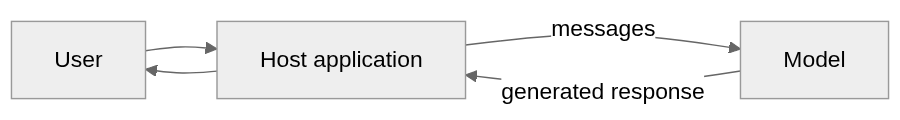

*D01 — the host application sends messages to the model and returns the reply*

### Step 1 — Send a message list, get a reply

A request is a list of dictionaries with a `role` and `content`. Two roles for now:
`system` (standing instructions) and `user` (the current task).

In [ ]:
messages = [
    {"role": "system", "content": "You are a concise tutor for engineering students."},
    {"role": "user", "content": "Explain recursion in three sentences."},
]
reply = chat(messages)

print("REPLY TEXT:\n", reply["content"])
print("\nUSAGE     :", reply["usage"])      # tokens in + tokens out = what you pay for

### Step 2 — The model forgets everything between calls

Send a fact in one call, ask about it in a *fresh* call. The model cannot answer, because the
second request never contained the fact. A conversation only "remembers" when the program
re-sends the earlier messages.

In [ ]:
first = chat([{"role": "user", "content": "My name is Aurora. Please remember it."}])
print("call 1 :", first["content"][:80])

# A brand-new message list: the earlier message is NOT included.
second = chat([{"role": "user", "content": "What is my name?"}])
print("call 2 :", second["content"])

# Re-send the history and the model can answer.
third = chat([
    {"role": "user", "content": "My name is Aurora. Please remember it."},
    {"role": "assistant", "content": first["content"]},
    {"role": "user", "content": "What is my name?"},
])
print("call 3 :", third["content"], "   <- only because WE re-sent the history")

### Step 3 — The context window and `max_tokens`

Everything in one request, plus the reply being generated, must fit in the model's **context
window** (a fixed token budget). `max_tokens` caps only the reply. Set it too low and the answer
is cut off mid-sentence; on reasoning models some of it is spent on hidden reasoning first.

In [ ]:
short = chat(messages, max_tokens=40)
print("with max_tokens=40 :", repr(short["content"][:160]))
print("\nThe mock ignores max_tokens; the live model truncates. Either way, the LIMIT belongs to your request, not to the model.")

### Live observation

If you are in LIVE mode, run Step 1 twice and compare the two replies: the wording differs
slightly even at `temperature=0`, but the usage record and the structure of the reply are the
same. That variability is why later sections validate outputs instead of trusting wording.

### Checkpoint

**1. The model answered a recursion question. Did any Python run inside the model, and where did the length limit come from?**

<details><summary>Show answer</summary>

No Python ran. The model only generated text. The limit came from `max_tokens` in the request *we* built.

</details>

**2. Why could call 2 not answer, but call 3 could?**

<details><summary>Show answer</summary>

Call 2 was a new request containing only the question. Call 3 contained the earlier messages again. The model has no memory; the program supplies continuity by re-sending history.

</details>

### Recap

- **Limitation seen:** one call is one text-in, text-out operation; nothing persists.
- **Layer added:** a message list built by our code, plus a `chat()` helper we control.
- **Evidence:** call 2 failed and call 3 succeeded, differing only in what we sent.